<a href="https://colab.research.google.com/github/MRigoni10/telco-churn-explainable-ai/blob/main/telco_churn_explainable_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Installazione librerie per Explainable AI e Gradient Boosting
!pip install -q xgboost shap

# 2. Import librerie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)
from xgboost import XGBClassifier

# Visual setting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# 3. Caricamento dataset IBM Telco via URL diretto

# URL diretto e stabile del dataset Telco Customer Churn
url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df_raw = pd.read_csv(url)
print(f"Dataset caricato con successo! Righe: {df_raw.shape[0]}, Colonne: {df_raw.shape[1]}")
df_raw.head()

Dataset caricato con successo! Righe: 7043, Colonne: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
def clean_churn_data(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    # 1. Rimozione ID univoco (non predittivo)
    df = df.drop(columns=['customerID'])

    # 2. Correzione tipo di dato per TotalCharges
    # Gli spazi vuoti diventano NaN, poi convertiti a 0 (clienti con tenure = 0)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

    # 3. Conversione target 'Churn' in binario (1: Abbandono, 0: Rimasto)
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    # 4. Semplificazione categorie ridondanti (es. 'No internet service' -> 'No')
    cols_replace_no_internet = [
        'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    for col in cols_replace_no_internet:
        df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

    # 5. One-Hot Encoding delle variabili categoriche
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

    return df_encoded

df_clean = clean_churn_data(df_raw)
print(f"Distribuzione Target Churn:\n{df_clean['Churn'].value_counts(normalize=True).round(3) * 100}%")

df_clean.head()

Distribuzione Target Churn:
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64%


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
# 1. Separazione Feature e Target
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# 2. Train-Test Split (80/20) con stratificazione
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Calcolo del rapporto di sbilanciamento (Negative Class / Positive Class)
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# 4. Inizializzazione e Addestramento Modello XGBoost
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predizioni probabilistiche e binarie
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metriche Tecniche
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"=== PERFORMANCE TECNICHE ===")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score:  {pr_auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churn (1)']))

# Matrice di Confusione
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# --- BUSINESS CASE SIMULATION ---
# Assunzioni economiche:
clv_salvato = 500       # Valore medio preservato per ogni cliente trattenuto
costo_retention = 50    # Costo dell'offerta/campagna inviata
tasso_accettazione = 0.40 # Il 40% dei clienti a rischio accetta l'offerta e non abbandona

# Calcolo Valore Netto
clienti_salvati = int(tp * tasso_accettazione)
valore_recuperato = clienti_salvati * clv_salvato
costo_totale_campagna = (tp + fp) * costo_retention
net_profit_retention = valore_recuperato - costo_totale_campagna

print(f"=== IMPATTO ECONOMICO SUL TEST SET ({len(y_test)} clienti) ===")
print(f"- Clienti Churn Intercettati Correttamente (TP): {tp}")
print(f"- Falsi Positivi (offerte inviate a chi non avrebbe abbandonato): {fp}")
print(f"- Costo Campagna Retention: €{costo_totale_campagna:,.2f}")
print(f"- Valore Clienti Effettivamente Salvati: €{valore_recuperato:,.2f}")
print(f"- **ROI Netto Generato dal Modello**: €{net_profit_retention:,.2f}")

=== PERFORMANCE TECNICHE ===
ROC-AUC Score: 0.8434
PR-AUC Score:  0.6577

              precision    recall  f1-score   support

Retained (0)       0.91      0.73      0.81      1035
   Churn (1)       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

=== IMPATTO ECONOMICO SUL TEST SET (1409 clienti) ===
- Clienti Churn Intercettati Correttamente (TP): 301
- Falsi Positivi (offerte inviate a chi non avrebbe abbandonato): 277
- Costo Campagna Retention: €28,900.00
- Valore Clienti Effettivamente Salvati: €60,000.00
- **ROI Netto Generato dal Modello**: €31,100.00


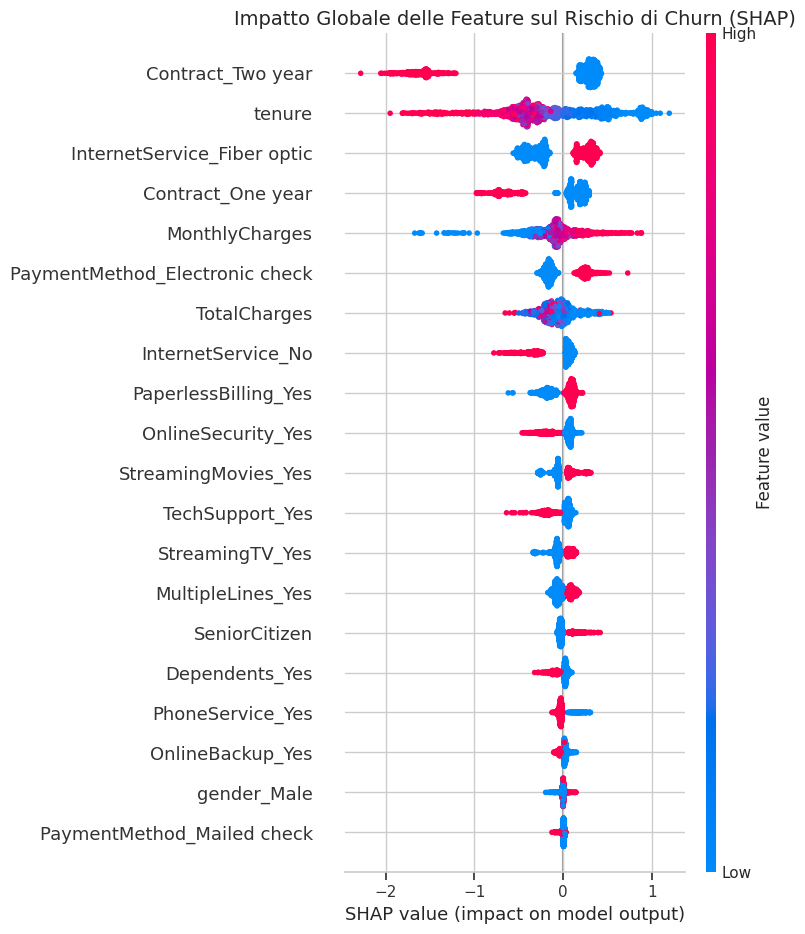

In [ ]:
# Calcolo dei valori SHAP con TreeExplainer (ottimizzato per XGBoost)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

# 1. Global Explainability: Quali feature pesano di più nel churn complessivo?
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("Impatto Globale delle Feature sul Rischio di Churn (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

Diagnosi per il Cliente ID Index 9:
Probabilità di Churn stimata: 59.7%


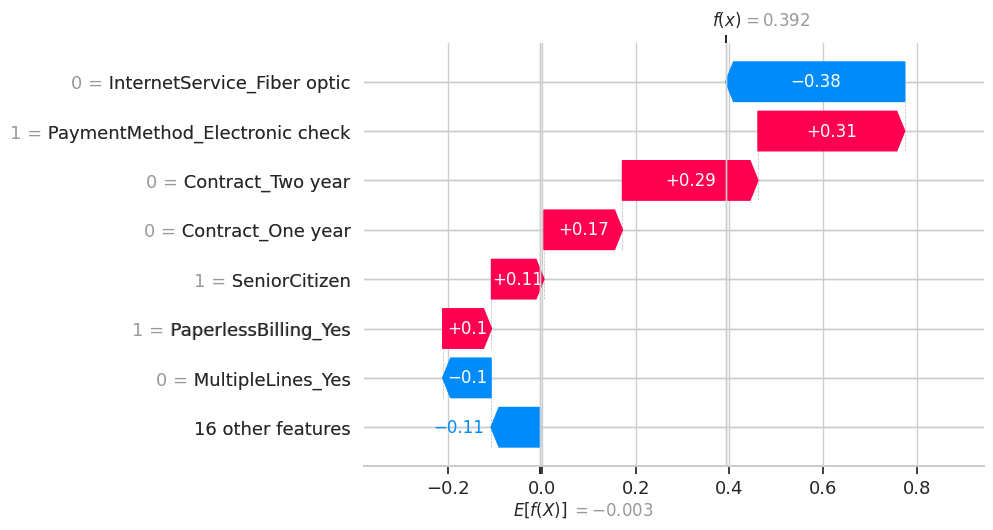

In [ ]:
# 2. Local Explainability: Diagnosi per un singolo cliente a rischio
# Selezioniamo il primo cliente classificato ad alto rischio
high_risk_idx = np.where((y_pred == 1) & (y_test.values == 1))[0][0]

print(f"Diagnosi per il Cliente ID Index {high_risk_idx}:")
print(f"Probabilità di Churn stimata: {y_pred_proba[high_risk_idx]*100:.1f}%")

shap.plots.waterfall(shap_values[high_risk_idx], max_display=8)